<a href="https://colab.research.google.com/github/DebasisMahata/Debasis/blob/main/Bird_Species_Observation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import missingno as ms
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
from PIL import Image
from IPython.display import display
import statsmodels as stat
import geopandas as geo

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset1 = pd.read_excel('/content/drive/My Drive/data/Bird_Monitoring_Data_FOREST.XLSX')
dataset2 = pd.read_excel('/content/drive/My Drive/data/Bird_Monitoring_Data_GRASSLAND.XLSX')
# Display the first few rows of one of the datasets to confirm it's loaded correctly
display(dataset1.head())

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,NPSTaxonCode,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,83803,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,90935,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,84865,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,93634,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,88394,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


NameError: name 'df' is not defined

In [ ]:
df = pd.concat([dataset1, dataset2], ignore_index=True)
display(df.head())
print(f"Shape of the merged DataFrame: {df.shape}")

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,TaxonCode,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,NaN,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,NaN,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,...,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN,NaN


Shape of the merged DataFrame: (3921, 31)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3921 entries, 0 to 3920
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Admin_Unit_Code              3921 non-null   object        
 1   Sub_Unit_Code                0 non-null      float64       
 2   Site_Name                    333 non-null    object        
 3   Plot_Name                    3921 non-null   object        
 4   Location_Type                3921 non-null   object        
 5   Year                         3921 non-null   int64         
 6   Date                         3921 non-null   datetime64[ns]
 7   Start_Time                   3921 non-null   object        
 8   End_Time                     3921 non-null   object        
 9   Observer                     3921 non-null   object        
 10  Visit                        3921 non-null   int64         
 11  Interval_Length              3921 non-null 

In [ ]:
# Dataset Duplicate Value Count
duplicates = df.duplicated(keep=False)

# Count the duplicate values
duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    3172
True      749
Name: count, dtype: int64


In [ ]:
df.drop_duplicates(keep='first', inplace=True)
print(f"Shape of the DataFrame after removing duplicates: {df.shape}")

Shape of the DataFrame after removing duplicates: (3463, 31)


In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
Admin_Unit_Code,0
Sub_Unit_Code,3463
Site_Name,3130
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0


In [ ]:
# Dataset Columns
df.columns

Index(['Admin_Unit_Code', 'Sub_Unit_Code', 'Site_Name', 'Plot_Name',
       'Location_Type', 'Year', 'Date', 'Start_Time', 'End_Time', 'Observer',
       'Visit', 'Interval_Length', 'ID_Method', 'Distance', 'Flyover_Observed',
       'Sex', 'Common_Name', 'Scientific_Name', 'AcceptedTSN', 'NPSTaxonCode',
       'AOU_Code', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
       'Temperature', 'Humidity', 'Sky', 'Wind', 'Disturbance',
       'Initial_Three_Min_Cnt', 'TaxonCode', 'Previously_Obs'],
      dtype='object')

In [ ]:
# Dataset Describe
df.describe()

,Sub_Unit_Code,Year,Date,Visit,AcceptedTSN,NPSTaxonCode,Temperature,Humidity,TaxonCode
count,0.0,3463.0,3463,3463.000000,3447.000000,333.000000,3463.000000,3463.000000,3129.000000
mean,NaN,2018.0,2018-06-18 20:01:43.956107520,1.908750,199397.257905,112177.567568,23.780046,69.340341,102680.635027
min,NaN,2018.0,2018-05-22 00:00:00,1.000000,174999.000000,82737.000000,12.900000,32.900002,76625.000000
25%,NaN,2018.0,2018-05-24 00:00:00,1.000000,178620.000000,85791.000000,21.000000,59.500000,84790.000000
50%,NaN,2018.0,2018-06-25 00:00:00,2.000000,179150.000000,88071.000000,23.500000,70.099998,87391.000000
75%,NaN,2018.0,2018-07-13 00:00:00,3.000000,179443.000000,94228.000000,26.700001,80.300003,94215.000000
max,NaN,2018.0,2018-07-19 00:00:00,3.000000,950052.000000,926917.000000,37.299999,93.300003,926917.000000
std,NaN,0.0,NaN,0.806022,92160.215144,88740.680703,4.899465,13.818066,83021.558825


In [ ]:
df.isnull().sum()

,0
Admin_Unit_Code,0
Sub_Unit_Code,3463
Site_Name,3130
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0


In [ ]:
df.isnull().sum()

,0
Admin_Unit_Code,0
Sub_Unit_Code,3463
Site_Name,3130
Plot_Name,0
Location_Type,0
Year,0
Date,0
Start_Time,0
End_Time,0
Observer,0


***Data Vizualization, Storytelling***




### Bird Observations Over Time (by Year)

Let's examine how the number of bird observations has changed across different years. This can highlight trends in monitoring activity or bird populations.

/tmp/ipykernel_152/1933027401.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=year_counts.index, y=year_counts.values, palette='viridis')


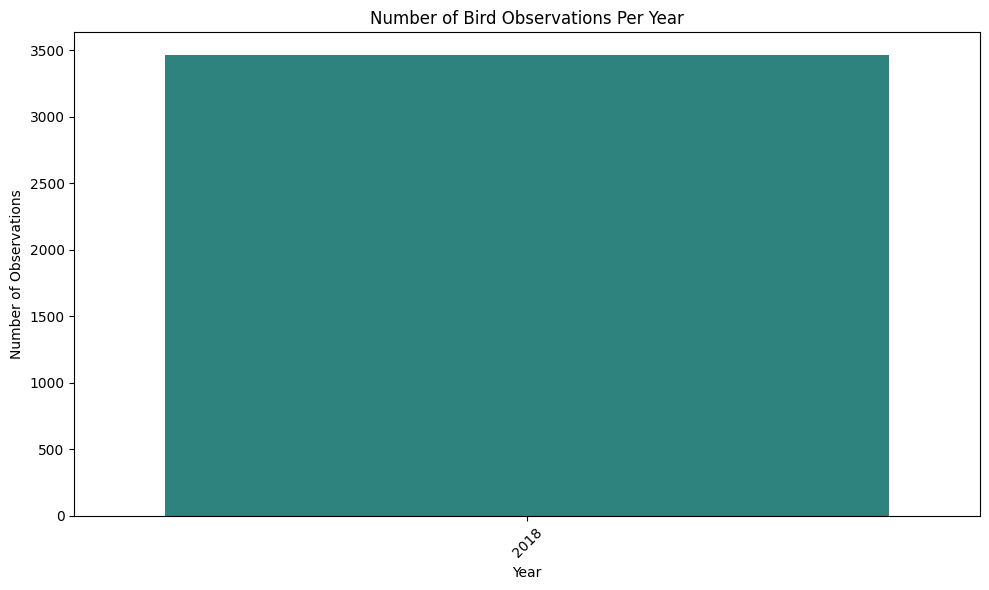

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the count of observations for each year
year_counts = df['Year'].value_counts().sort_index()

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=year_counts.index, y=year_counts.values, palette='viridis')
plt.title('Number of Bird Observations Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Top 5 Most Common Bird Species in Forest (Pie Chart)

Now, let's visualize the top 5 most common bird species specifically in **forest** areas using a pie chart to show their relative proportions, similar to what we did for grassland.

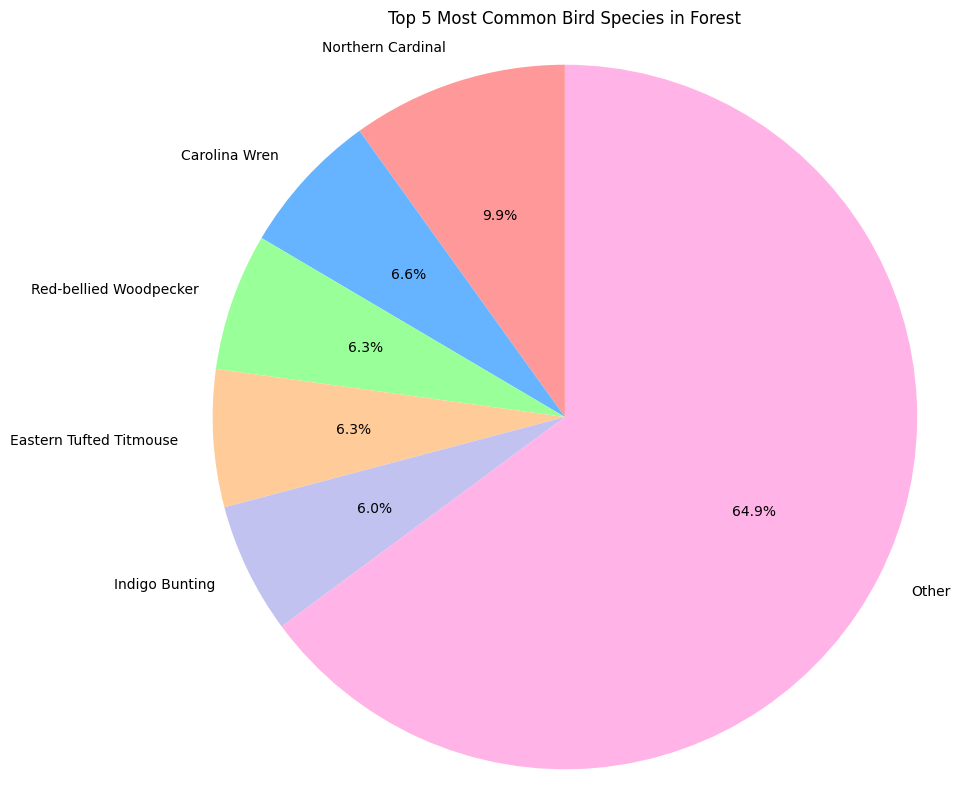

In [ ]:
import matplotlib.pyplot as plt

# Filter for 'Forest' locations
forest_df = df[df['Location_Type'] == 'Forest']

# Get the value counts for common names in forest
forest_species_counts = forest_df['Common_Name'].value_counts()

# Get the top 5 species
top_5_forest_species = forest_species_counts.head(5)

# Calculate the sum of the remaining species for 'Other'
other_species_count = forest_species_counts[5:].sum()

# Combine top 5 and 'Other' into a new series for plotting
plot_data_forest = pd.concat([top_5_forest_species, pd.Series({'Other': other_species_count})])

# Create a pie chart with a new color palette
plt.figure(figsize=(10, 10))
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0', '#ffb3e6'] # A new color palette
plt.pie(plot_data_forest, labels=plot_data_forest.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Top 5 Most Common Bird Species in Forest')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Top 5 Most Common Bird Species in Grassland (Pie Chart)

Let's visualize the top 5 most common bird species specifically in grassland areas using a pie chart to show their relative proportions.

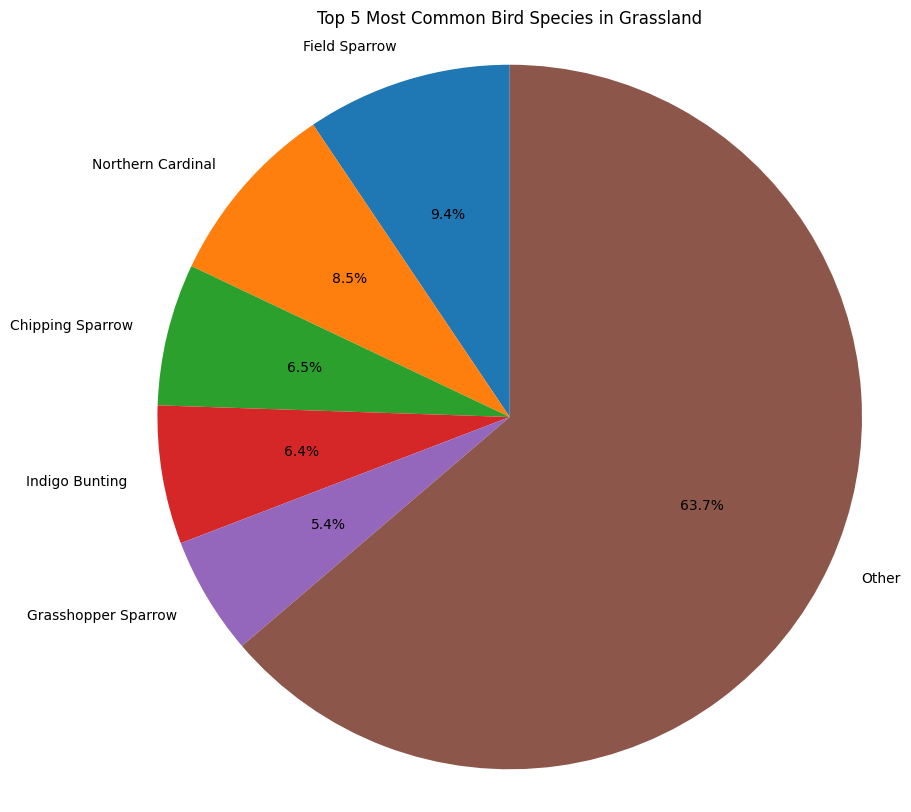

In [ ]:
import matplotlib.pyplot as plt

# Filter for 'Grassland' locations
grassland_df = df[df['Location_Type'] == 'Grassland']

# Get the value counts for common names in grassland
grassland_species_counts = grassland_df['Common_Name'].value_counts()

# Get the top 5 species
top_5_grassland_species = grassland_species_counts.head(5)

# Calculate the sum of the remaining species for 'Other'
other_species_count = grassland_species_counts[5:].sum()

# Combine top 5 and 'Other' into a new series for plotting
plot_data = pd.concat([top_5_grassland_species, pd.Series({'Other': other_species_count})])

# Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(plot_data, labels=plot_data.index, autopct='%1.1f%%', startangle=90)
plt.title('Top 5 Most Common Bird Species in Grassland')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

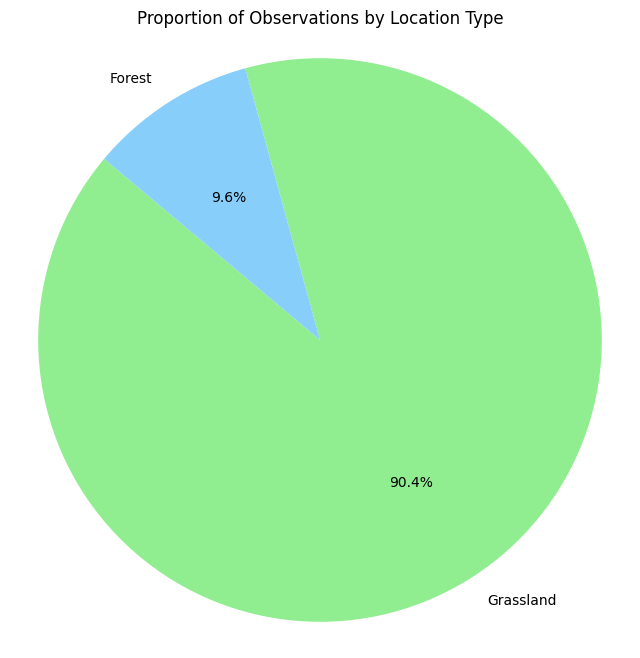

In [ ]:
import matplotlib.pyplot as plt

# Get the count of observations for each Location_Type
location_type_counts = df['Location_Type'].value_counts()

# Create a pie chart
plt.figure(figsize=(8, 8))
plt.pie(location_type_counts, labels=location_type_counts.index, autopct='%1.1f%%', startangle=140, colors=['lightgreen', 'lightskyblue'])
plt.title('Proportion of Observations by Location Type')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Temperature Distribution During Observations

Let's visualize the distribution of temperatures recorded during the bird observations. This can give us an idea of the typical temperature range during monitoring.

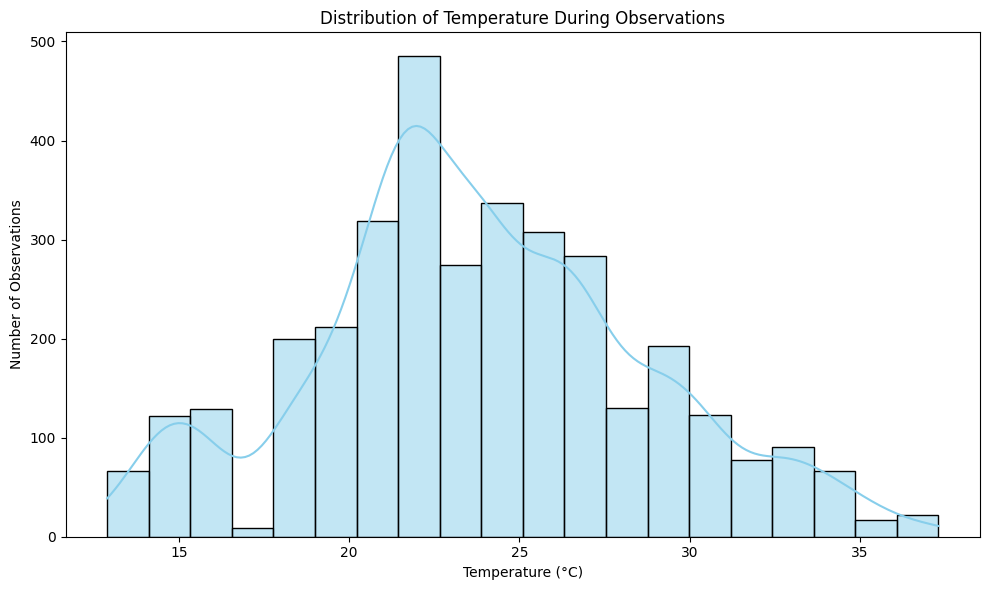

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Temperature'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Temperature During Observations')
plt.xlabel('Temperature (°C)')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

### Humidity Distribution During Observations

Now, let's look at the distribution of humidity levels recorded. This, along with temperature, provides context about the environmental conditions during the observations.

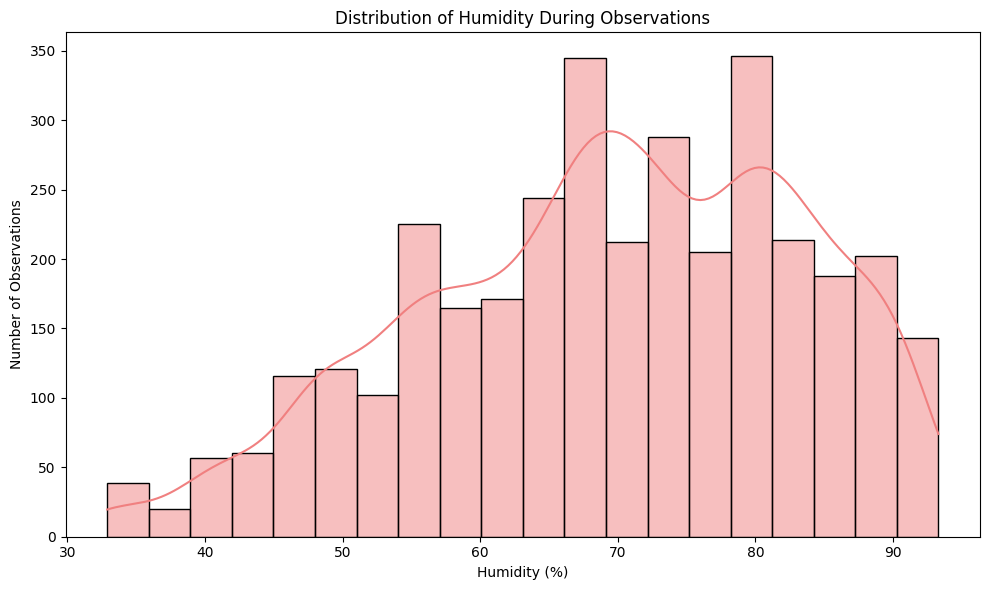

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Humidity'], bins=20, kde=True, color='lightcoral')
plt.title('Distribution of Humidity During Observations')
plt.xlabel('Humidity (%)')
plt.ylabel('Number of Observations')
plt.tight_layout()
plt.show()

### Sky Conditions Distribution

Understanding the sky conditions during observations can be important. Let's see how frequently different sky conditions were recorded.

/tmp/ipykernel_152/3681507285.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sky_counts.index, y=sky_counts.values, palette='pastel')


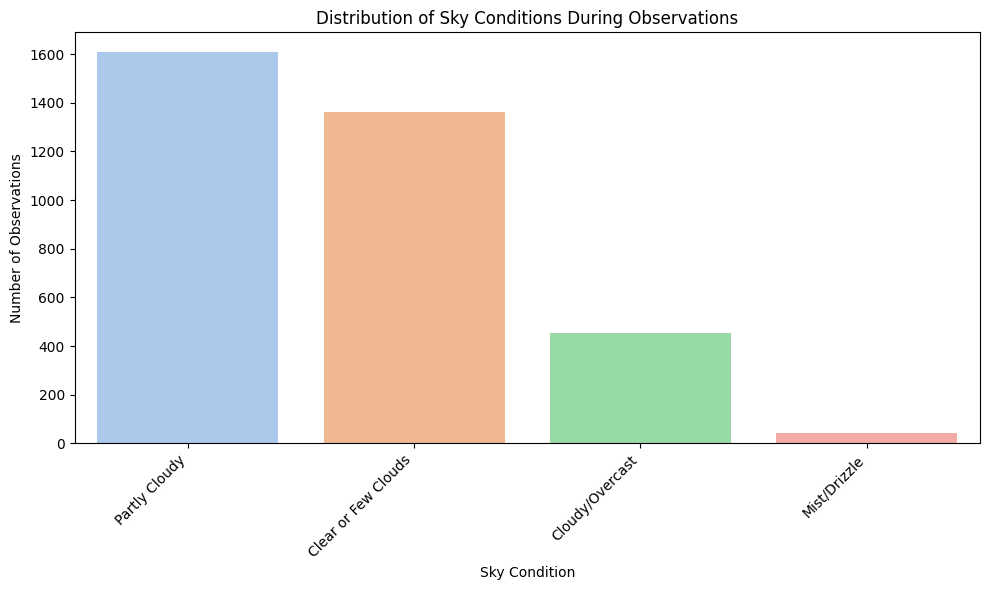

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sky_counts = df['Sky'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=sky_counts.index, y=sky_counts.values, palette='pastel')
plt.title('Distribution of Sky Conditions During Observations')
plt.xlabel('Sky Condition')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Wind Conditions Distribution

Wind conditions are another environmental factor that might influence bird activity or observation difficulty. Let's visualize their distribution.

/tmp/ipykernel_152/3927900559.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wind_counts.index, y=wind_counts.values, palette='rocket')


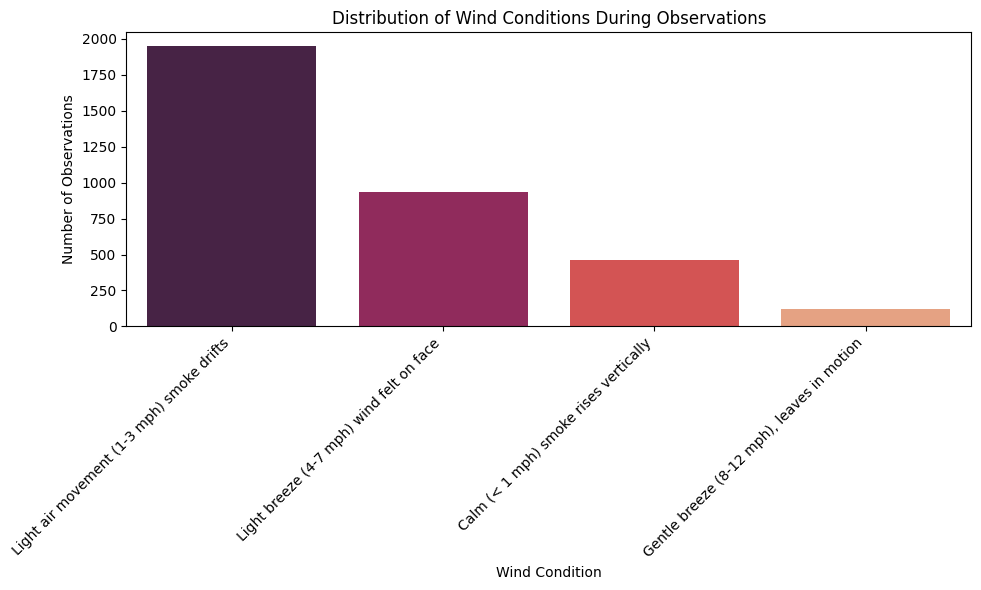

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

wind_counts = df['Wind'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=wind_counts.index, y=wind_counts.values, palette='rocket')
plt.title('Distribution of Wind Conditions During Observations')
plt.xlabel('Wind Condition')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Distribution of Bird Observations by Visit Number

Finally, let's look at how many observations were recorded during each visit number. This can give insight into the monitoring protocol or effort across different visits.

/tmp/ipykernel_152/1764645215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=visit_counts.index, y=visit_counts.values, palette='mako')


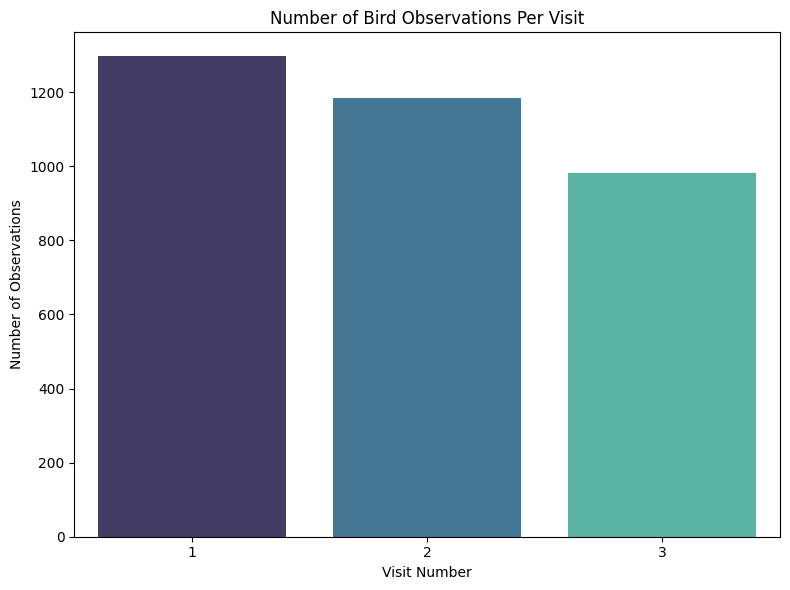

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

visit_counts = df['Visit'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=visit_counts.index, y=visit_counts.values, palette='mako')
plt.title('Number of Bird Observations Per Visit')
plt.xlabel('Visit Number')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Distribution of Bird Sexes Observed

Let's analyze the distribution of observed bird sexes to see if there's any notable pattern or if one sex is more frequently recorded than the other.

/tmp/ipykernel_152/4153164341.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='coolwarm')


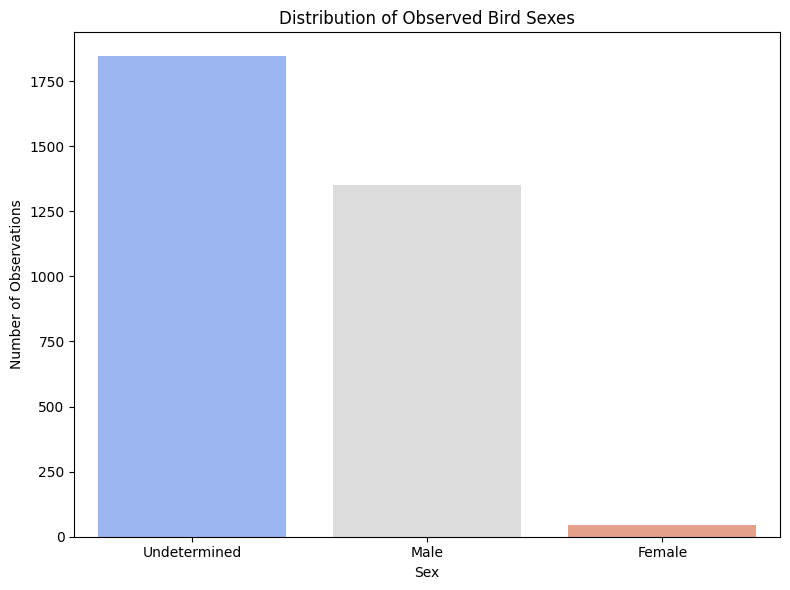

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the count of observations for each sex, handling potential NaN values
sex_counts = df['Sex'].value_counts(dropna=False)

# Create a bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=sex_counts.index, y=sex_counts.values, palette='coolwarm')
plt.title('Distribution of Observed Bird Sexes')
plt.xlabel('Sex')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Top 10 Most Common Bird Species

Let's visualize the distribution of the most frequently observed bird species to understand which ones are most prevalent in the monitoring data.

/tmp/ipykernel_152/1295654604.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_species.index, y=top_10_species.values, palette='viridis')


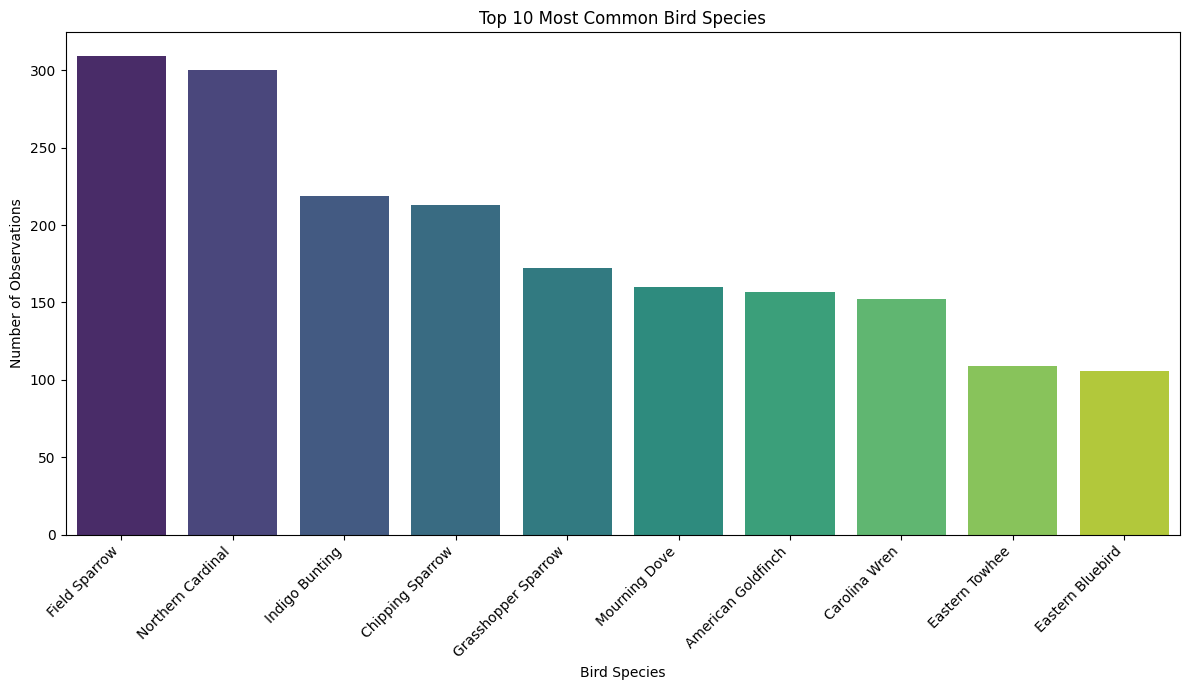

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 10 most common bird species
top_10_species = df['Common_Name'].value_counts().head(10)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_species.index, y=top_10_species.values, palette='viridis')
plt.title('Top 10 Most Common Bird Species')
plt.xlabel('Bird Species')
plt.ylabel('Number of Observations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()